# 1. Overview

In this analysis, we explore the unique features, traits, and behaviors of different dog breeds. We'll look at everything from the noble and dignified breeds to the fun-loving and playful ones. This data helps us understand the special qualities that make each breed stand out, giving us a deeper appreciation for the Man's best friend.

# 2. Import packages and data

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('dog_breeds.csv')
df.shape

# 3. Understanding the data

In [ ]:
df.head()

,Breed,type,score,popularity ranking,size,intelligence,congential ailments,score for kids,size.1,$LIFETIME COST,INTELLIGENCE RANK,INTELLIGENCE %,LONGEVITY(YEARS),NUMBER OF GENETIC AILMENTS,GENETIC AILMENTS,PURCHASE PRICE,FOOD COSTS PER YEAR,GROOMING FREQUNCY,SUITABILITY FOR CHILDREN
0,Border Terrier,terrier,3.61,61,1,Above average,none,4.99,small,"$22,638",30,70%,14.00,0,none,$833,$324,Once a week,1
1,Cairn Terrier,terrier,3.53,48,1,Above average,"'lion jaw', heart problems",4.91,small,"$21,992",35,61%,13.84,2,"'lion jaw', heart problems",$435,$324,Once a week,1
2,Siberian Husky,working,3.22,16,2,Average,none,4.72,medium,"$22,049",45,45%,12.58,0,none,$650,$466,Once in a few weeks,1
3,Welsh Springer Spaniel,sporting,3.34,81,2,Above average,hip problems,4.71,medium,"$20,224",31,69%,12.49,1,hip problems,$750,$324,Once a week,1
4,English Cocker Spaniel,sporting,3.33,51,2,Excellent,none,4.70,medium,"$18,993",18,82%,11.66,0,none,$800,$324,Once a week,1


In [ ]:
# 87 unique breeds of dogs
df.Breed.value_counts()

Breed
Border Terrier          1
Doberman Pinscher       1
Boxer                   1
Bernese Mountain Dog    1
French Bulldog          1
                       ..
Beagle                  1
Miniature Schnauzer     1
Affenpinscher           1
Pug                     1
Bulldog                 1
Name: count, Length: 87, dtype: int64

In [ ]:
# no missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Breed                       87 non-null     object 
 1   type                        87 non-null     object 
 2   score                       87 non-null     float64
 3   popularity ranking          87 non-null     int64  
 4   size                        87 non-null     int64  
 5   intelligence                87 non-null     object 
 6   congential ailments         87 non-null     object 
 7   score for kids              87 non-null     float64
 8   size.1                      87 non-null     object 
 9   $LIFETIME COST              87 non-null     object 
 10  INTELLIGENCE RANK           87 non-null     int64  
 11  INTELLIGENCE %              87 non-null     object 
 12  LONGEVITY(YEARS)            87 non-null     float64
 13  NUMBER OF GENETIC AILMENTS  87 non-nu

In [ ]:
# standardize column names
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['breed', 'type', 'score', 'popularity_ranking', 'size', 'intelligence',
       'congential_ailments', 'score_for_kids', 'size.1', '$lifetime_cost',
       'intelligence_rank', 'intelligence_%', 'longevity(years)',
       'number_of_genetic_ailments', 'genetic_ailments', 'purchase_price',
       'food_costs_per_year', 'grooming_frequncy', 'suitability_for_children'],
      dtype='object')

In [ ]:
df.describe()

,score,popularity_ranking,size,score_for_kids,intelligence_rank,longevity(years),number_of_genetic_ailments,suitability_for_children
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,2.603678,44.000000,1.954023,3.681839,41.540230,11.117701,1.689655,1.540230
std,0.570288,25.258662,0.819927,0.655736,21.979803,1.938465,1.707101,0.678655
min,0.990000,1.000000,1.000000,1.860000,1.000000,6.290000,0.000000,1.000000
25%,2.185000,22.500000,1.000000,3.180000,27.000000,10.000000,0.500000,1.000000
50%,2.710000,44.000000,2.000000,3.810000,43.000000,11.560000,1.000000,1.000000
75%,3.035000,65.500000,3.000000,4.115000,59.000000,12.430000,2.000000,2.000000
max,3.640000,87.000000,3.000000,4.990000,80.000000,16.500000,9.000000,3.000000


# 4. Exploratory data analysis

### Top 10 most popular breeds

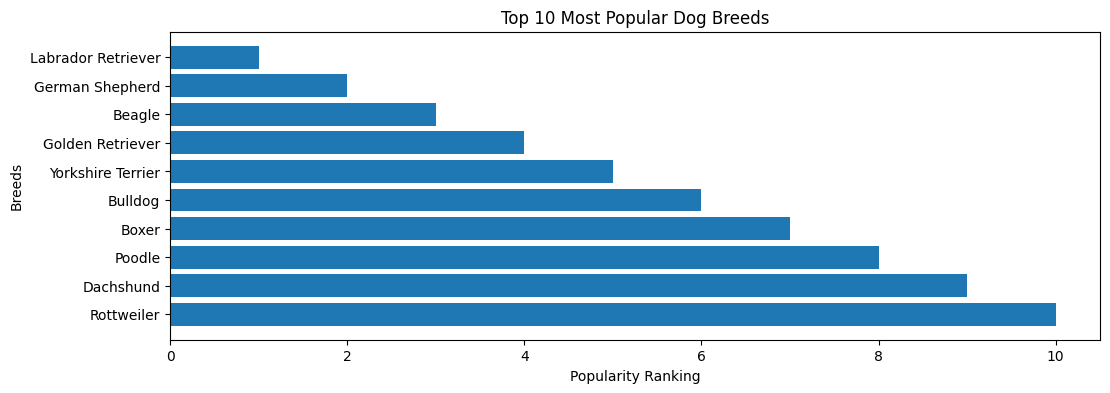

In [ ]:
# top 10 most popular breeds
top_10_popular = df.sort_values('popularity_ranking').head(10)

plt.figure(figsize=(12, 4))
plt.barh(top_10_popular['breed'][::-1], top_10_popular['popularity_ranking'][::-1])
plt.xlabel('Popularity Ranking')
plt.ylabel('Breeds')
plt.title('Top 10 Most Popular Dog Breeds')
plt.show()

The Labrador Retriever, German Shepherd, and Beagle being the top three most popular dog breeds in the world can be attributed to their unique traits and characteristics that make them appealing to a wide range of owners.

Labrador Retriever: Known for their friendly, outgoing, and gentle nature, Labrador Retrievers are often hailed as excellent family dogs. They are intelligent, easy to train, and have a natural affinity for children, making them a popular choice for households with kids. Additionally, their versatility as both companions and working dogs (e.g., service dogs, search and rescue) contributes to their widespread popularity.

German Shepherd: The German Shepherd's popularity can be attributed to its reputation as a loyal, protective, and highly intelligent breed. They are often praised for their versatility, excelling in various roles such as police work, military service, and family guardians. Their athletic build, trainability, and strong work ethic make them a sought-after breed for those seeking a reliable and capable companion.

Beagle: The Beagle's popularity stems from its charming personality and compact size, making it a suitable choice for both urban and suburban living. These friendly and curious dogs are known for their affectionate nature and ability to get along with children and other pets. Their relatively low-maintenance grooming requirements and adaptability to different living situations also contribute to their widespread appeal.

### Features correlation

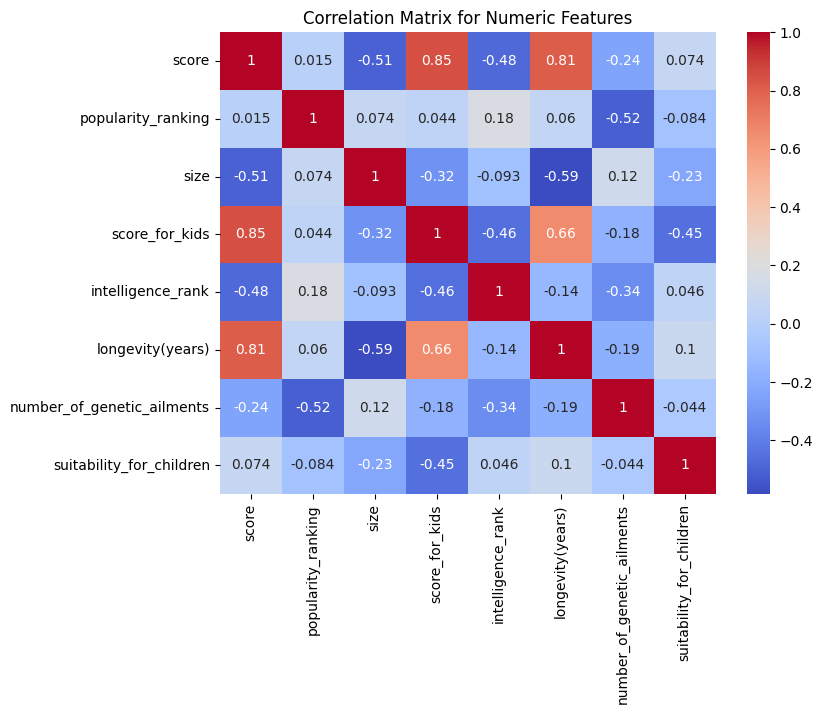

In [ ]:
# get numeric features (int & float)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_data = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Numeric Features')
plt.show()

There is a relatively high positive correlation between score for kids and longevity, suggesting that kid-friendly breeds tend to have longer lifespans. This relationship is intuitive because dogs that are kid-friendly tend to form strong emotional bonds with their human families. This emotional connection and the companionship they provide can contribute to the overall well-being and happiness of both the dog and the family members, potentially leading to a longer lifespan of the dog.

### Longevity and score with kids

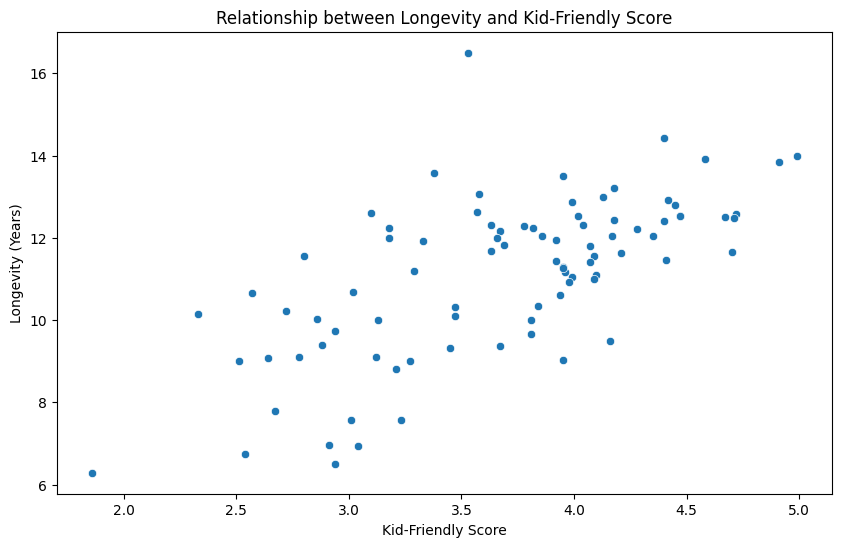

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(y='longevity(years)', x='score_for_kids', data=df)
plt.ylabel('Longevity (Years)')
plt.xlabel('Kid-Friendly Score')
plt.title('Relationship between Longevity and Kid-Friendly Score')
plt.show()

Let's fit a linear regression line to visualize the relationship between longevity and kid-friendly score

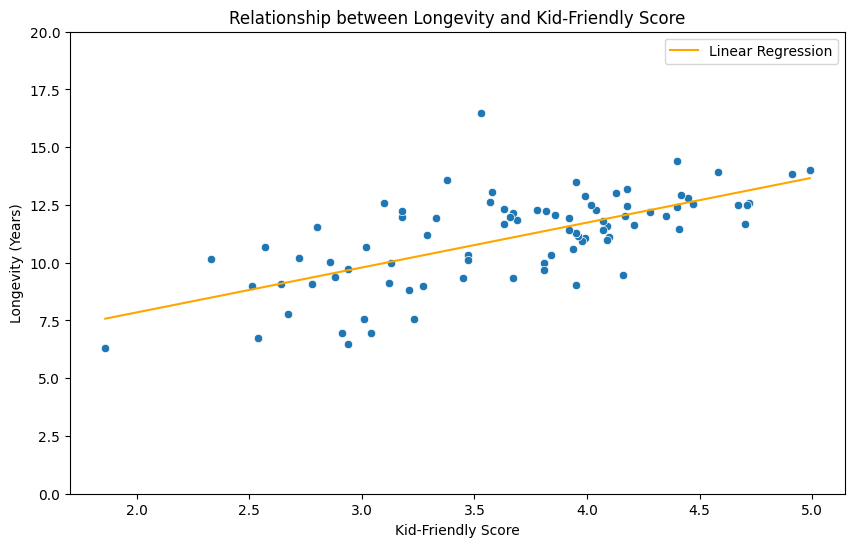

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(y='longevity(years)', x='score_for_kids', data=df)
plt.ylabel('Longevity (Years)')
plt.xlabel('Kid-Friendly Score')
plt.title('Relationship between Longevity and Kid-Friendly Score')

X = df['score_for_kids'].values.reshape(-1,1)
y = df['longevity(years)'].values

# fit linear regression
lr = LinearRegression()
lr.fit(X, y)

# plot regression line
x_range = np.linspace(df['score_for_kids'].min(), df['score_for_kids'].max(), 100)
y_range = lr.predict(x_range.reshape(-1,1))
plt.plot(x_range, y_range, color= 'orange', label='Linear Regression')
plt.legend()
plt.ylim(0,20)
plt.show()

### Understanding intelligence and purchase price

In [ ]:
df.intelligence.value_counts()

intelligence
Average          21
Above average    19
Fair             15
Excellent        11
Lowest           11
Brightest        10
Name: count, dtype: int64

In [ ]:
intelligence_mapping = {
    'Lowest': 1,
    'Fair': 2,
    'Average': 3,
    'Above average': 4,
    'Excellent': 5,
    'Brightest': 6
}

df['intelligence_mapped'] = df['intelligence'].map(intelligence_mapping)
df.head()

,breed,type,score,popularity_ranking,size,intelligence,congential_ailments,score_for_kids,size.1,$lifetime_cost,intelligence_rank,intelligence_%,longevity(years),number_of_genetic_ailments,genetic_ailments,purchase_price,food_costs_per_year,grooming_frequncy,suitability_for_children,intelligence_mapped
0,Border Terrier,terrier,3.61,61,1,Above average,none,4.99,small,"$22,638",30,70%,14.00,0,none,$833,$324,Once a week,1,4
1,Cairn Terrier,terrier,3.53,48,1,Above average,"'lion jaw', heart problems",4.91,small,"$21,992",35,61%,13.84,2,"'lion jaw', heart problems",$435,$324,Once a week,1,4
2,Siberian Husky,working,3.22,16,2,Average,none,4.72,medium,"$22,049",45,45%,12.58,0,none,$650,$466,Once in a few weeks,1,3
3,Welsh Springer Spaniel,sporting,3.34,81,2,Above average,hip problems,4.71,medium,"$20,224",31,69%,12.49,1,hip problems,$750,$324,Once a week,1,4
4,English Cocker Spaniel,sporting,3.33,51,2,Excellent,none,4.70,medium,"$18,993",18,82%,11.66,0,none,$800,$324,Once a week,1,5


In [ ]:
df.purchase_price = df.purchase_price.str.replace('$','').str.replace(',','').astype(float)

<Axes: xlabel='intelligence_mapped', ylabel='purchase_price'>

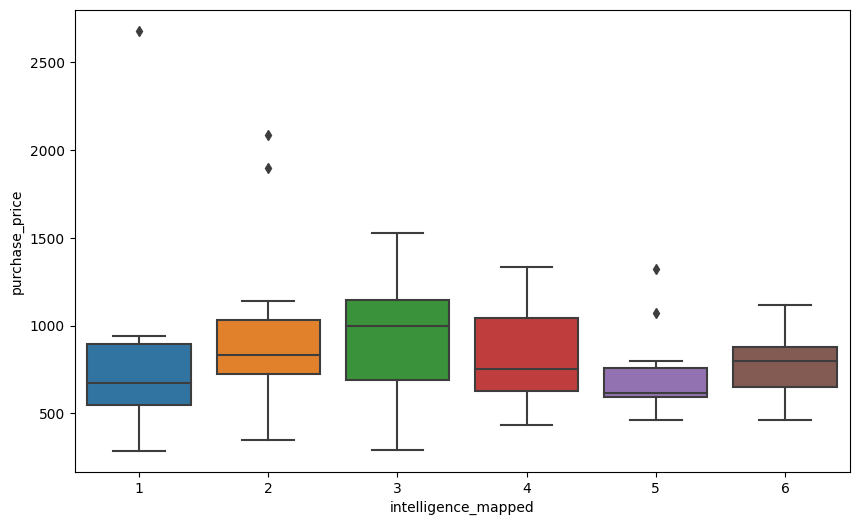

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x='intelligence_mapped', y='purchase_price', data=df)

The analysis of the relationship between intelligence and purchase price reveals no strong correlation between the two variables. The boxplot illustrates that the purchase price remains within a similar range across all levels of intelligence, from the lowest to the brightest. This indicates that intelligence, as measured in this dataset, does not significantly influence or predict the amount spent on purchases. The consistency in purchase price distribution across varying intelligence levels suggests that other factors, beyond intelligence, are likely driving purchase behaviors and decisions.

### Genetic ailments and breed type

In [ ]:
df.type.value_counts()

type
sporting        15
working         14
toy             13
hound           13
terrier         12
non-sporting    10
herding         10
Name: count, dtype: int64

In [ ]:
df.genetic_ailments.value_counts()

genetic_ailments
none                                                                                                   22
hip problems                                                                                           12
heart problems                                                                                          3
deafness, hip problems                                                                                  2
knee problems                                                                                           2
eye, hip problems                                                                                       2
heart, spine, blood clotting disorders                                                                  1
hip problems, heart defects                                                                             1
kidney, eye problems, anaemia                                                                           1
meningitis, elbow + hip probl

In [ ]:
df['genetic_ailments_present'] = df['genetic_ailments'].apply(lambda x: 0 if x=='none' else 1)
df['genetic_ailments_present'].value_counts()

genetic_ailments_present
1    65
0    22
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

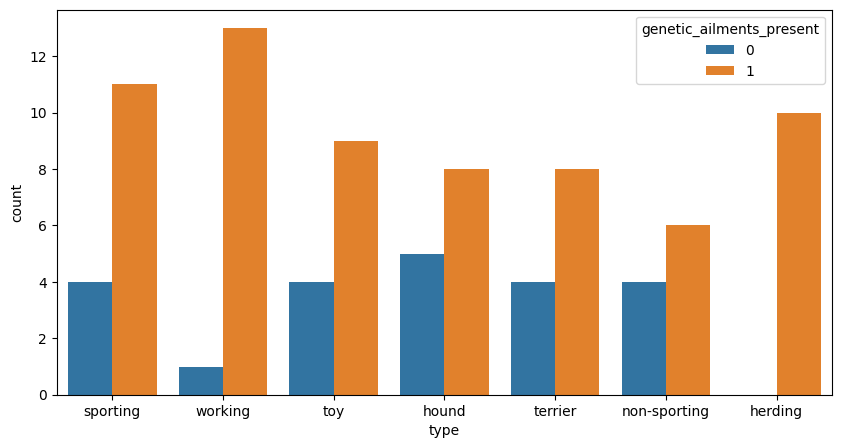

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(df, x='type', order=df['type'].value_counts().index, hue='genetic_ailments_present')

Breeds categorized as 'working', 'herding', and 'sporting' exhibit the highest proportion of genetic ailments. Understanding these breed-specific predispositions is essential for informed breeding practices and responsible pet ownership.

### Cost and score

In [ ]:
df[['breed', '$lifetime_cost', 'score']]

,breed,$lifetime_cost,score
0,Border Terrier,"$22,638",3.61
1,Cairn Terrier,"$21,992",3.53
2,Siberian Husky,"$22,049",3.22
3,Welsh Springer Spaniel,"$20,224",3.34
4,English Cocker Spaniel,"$18,993",3.33
...,...,...,...
82,Alaskan Malamute,"$21,986",1.82
83,Bloodhound,"$13,824",1.66
84,Chow Chow,"$15,898",1.76
85,Akita,"$20,994",1.95


In [ ]:
df['$lifetime_cost'] = df['$lifetime_cost'].str.replace('$','').str.replace(',','').astype(int)

(10000.0, 30000.0)

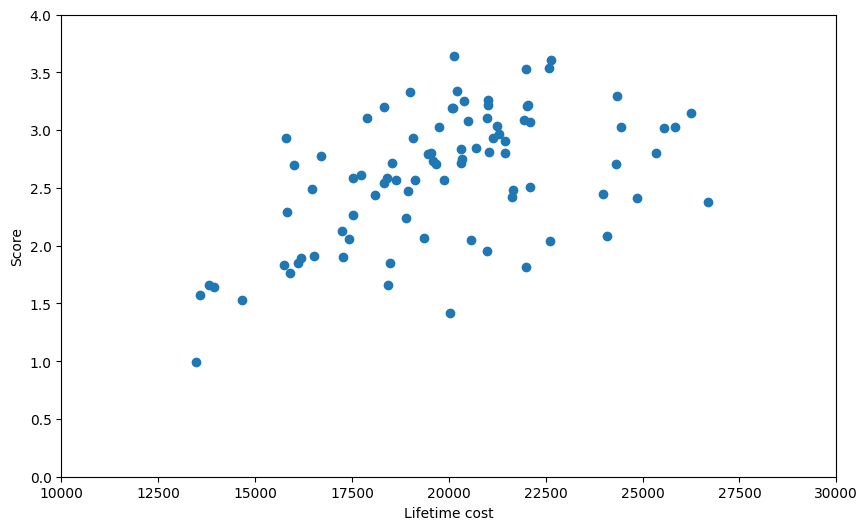

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['$lifetime_cost'], df['score'])
plt.xlabel('Lifetime cost')
plt.ylabel('Score')
plt.ylim(0,4)
plt.xlim(10000,30000)

Dogs with better scores generally cost more to take care of over their lifetime. This suggests that breeds with desirable traits usually come with higher expenses for things like healthcare and grooming. On the other hand, breeds with lower scores may have lower lifetime costs because they might need less specialized care. Overall, this highlights the importance of considering both the upfront cost and long-term expenses when choosing a dog breed. It helps people make informed decisions based on their budget and what they want in a furry friend.






